In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
t = np.arange(500, 10001, 500)	# going from 500 ns to 10 us in 500 ns jumps
datas = {}
for pulse_length in t:
	data = np.loadtxt(rf"{str(pulse_length)}ns.txt")
	datas[pulse_length] = data

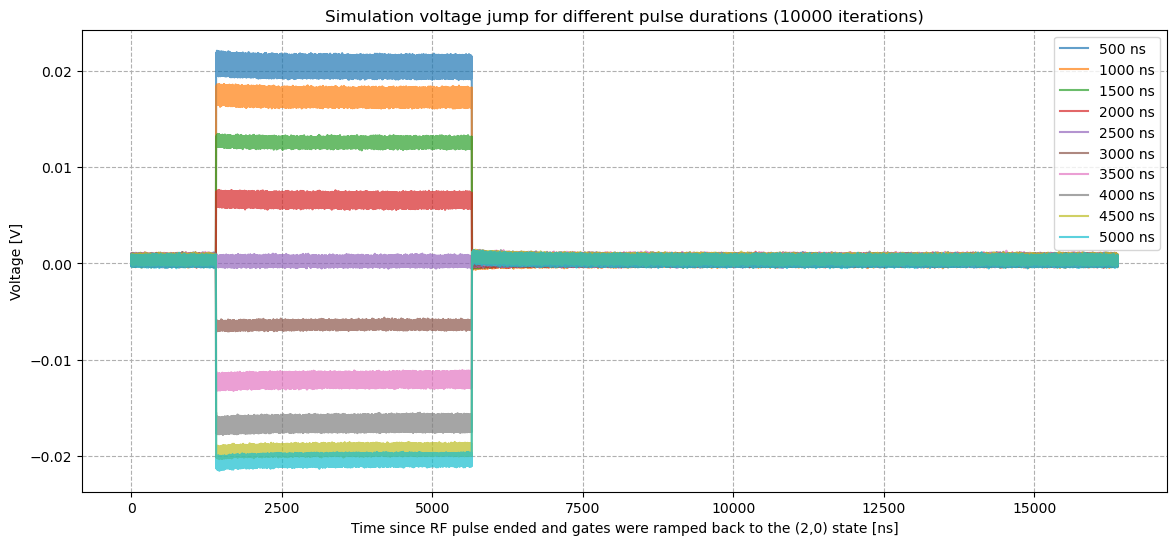

[0.002188568637029799, 0.0019736199316072317, 0.0008939912066438689, 0.0014411333659013177, 0.0009233023937469467, 0.0007523204689789944, 0.0013141182217879816, 0.0013629702002931135, 0.0011333659013190063, 0.0012848070346849066]


In [3]:
noise = []
fig, ax = plt.subplots(1, 1, figsize = (14, 6))
for pulse_length in t[:10]:
	ax.plot(datas[pulse_length][:], alpha = 0.7,  label = f"{pulse_length} ns")
	#ax.scatter(np.arange(0, 100), datas[pulse_length][3300:3400], alpha = 0.7)
	noise.append(abs(datas[pulse_length][3300] - datas[pulse_length][3301]))
ax.set_title("Simulation voltage jump for different pulse durations (10000 iterations)")
ax.set_ylabel("Voltage [V]")
ax.set_xlabel("Time since RF pulse ended and gates were ramped back to the (2,0) state [ns]")
ax.grid(True, which = "both", ls = "--")
plt.legend()
plt.show()
print(noise)

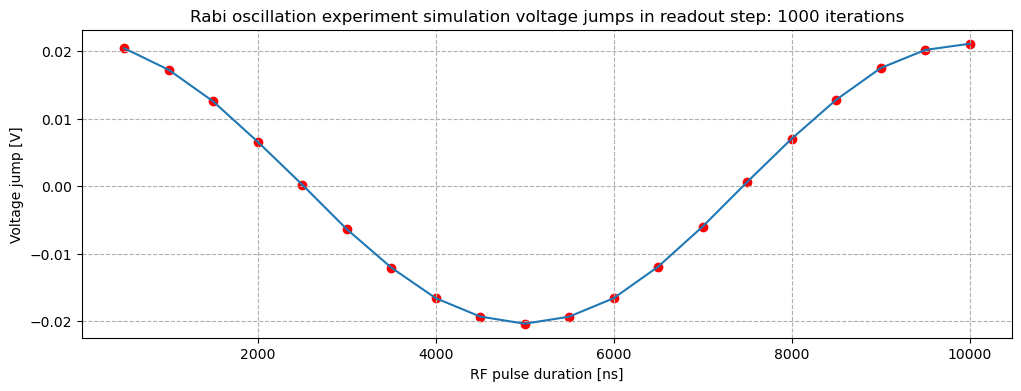

In [4]:
# Identifying jump heights
lo = 2800
hi = 5500

jumps = []
for pulse_length in t:
	jump = sum(datas[pulse_length][lo:hi])/len(datas[pulse_length][lo:hi])	
	jumps.append(jump)

fig, ax = plt.subplots(1, 1, figsize = (12, 4))
ax.plot(t, jumps)
ax.scatter(t, jumps, color = "r")
ax.set_title("Rabi oscillation experiment simulation voltage jumps in readout step: 1000 iterations")
ax.set_ylabel("Voltage jump [V]")
ax.set_xlabel("RF pulse duration [ns]")
ax.grid(True, which = "both", ls = "--")
plt.show()